<a href="https://colab.research.google.com/github/allenphos/Study-projects/blob/main/Computer_Vision_with_PyTorch_ua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Імпортуємо PyTorch
import torch
from torch import nn

# Імпортуємо torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


In [ ]:
# Налаштування навчальних даних
train_data = datasets.MNIST(
    root="data", # куди завантажити дані?
    train=True, # отримати навчальні дані
    download=True, # завантажити дані, якщо їх немає на диску
    transform=ToTensor(), # зображення приходять у форматі PIL, ми хочемо перетворити їх на тензори Torch
    target_transform=None # ви також можете перетворити мітки
)

# Налаштування тестових даних
test_data = datasets.MNIST(
    root="data",
    train=False, # отримати тестові дані
    download=True,
    transform=ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.26MB/s]


In [ ]:
print('Скільки елементів в кожному наборі', len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets))
image, label = train_data[0]
class_names = train_data.classes
print("Формат (розмірності) кожної картинки", image.shape)
print("Класи представлені в цьому наборі даних", class_names)

Скільки елементів в кожному наборі 60000 60000 10000 10000
Формат (розмірності) кожної картинки torch.Size([1, 28, 28])
Класи представлені в цьому наборі даних ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


## 4. Візуалізація

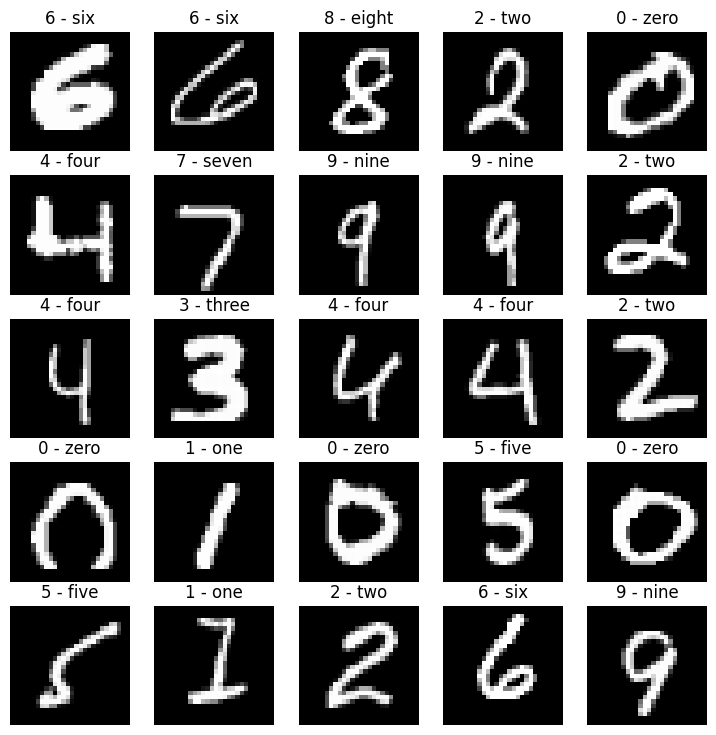

In [ ]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 5, 5
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

## 5. Перетворення навчальних та тестових наборів даних MNIST

In [ ]:
from torch.utils.data import DataLoader

# Налаштування гіперпараметра розміру партії
BATCH_SIZE = 32

# Перетворення наборів даних на ітерабельні (партії)
train_dataloader = DataLoader(train_data, # набір даних, який потрібно перетворити на ітерабельний
    batch_size=BATCH_SIZE, # скільки зразків на партію?
    shuffle=True # перемішувати дані на кожній епосі?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # не обов'язково перемішувати тестові дані
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Довжина навчального dataloader: {len(train_dataloader)} партій по {BATCH_SIZE}")
print(f"Довжина тестового dataloader: {len(test_dataloader)} партій по {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7c22776940d0>, <torch.utils.data.dataloader.DataLoader object at 0x7c227aa83090>)
Довжина навчального dataloader: 1875 партій по 32
Довжина тестового dataloader: 313 партій по 32


In [ ]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Розмір зображення: torch.Size([1, 28, 28])
Мітка: 9, розмір мітки: torch.Size([])


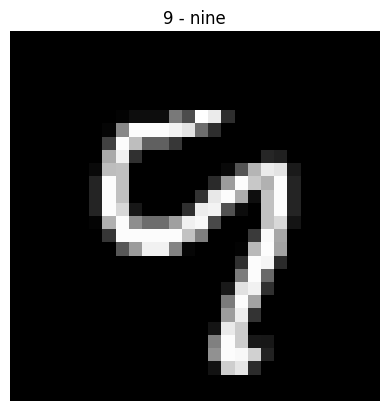

In [ ]:
# Показати зразок
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Розмір зображення: {img.shape}")
print(f"Мітка: {label}, розмір мітки: {label.shape}")

## 6. Відтворення `ModelV2`
[CNN Explainer](https://poloclub.github.io/cnn-explainer/)


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Створення згорткової нейронної мережі
class MNISTModelV2(nn.Module):
    """
    Архітектура моделі, що копіює TinyVGG з:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # якого розміру квадрат, що проходить по зображенню?
                      stride=1, # за замовчуванням
                      padding=1),# варіанти = "valid" (без заповнення) або "same" (вихід має таку ж форму, як вхід) або int для конкретного числа
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # значення кроку за замовчуванням таке ж, як і розмір ядра
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Звідки взялася ця форма in_features?
            # Це тому, що кожен шар нашої мережі стискає та змінює форму наших вхідних даних.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = MNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

MNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 7. Навчання моделі на CPU та GPU

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Відправка даних на GPU
        X, y = X.to(device), y.to(device)

        # 1. Прямий прохід
        y_pred = model(X)

        # 2. Обчислення втрат
        loss = loss_fn(y_pred, y)
        train_loss += loss
        # train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1)) # Original line
        train_acc += accuracy_fn(y_pred.argmax(dim=1), y) # Changed to positional arguments

        # 3. Обнулення градієнтів оптимізатора
        optimizer.zero_grad()

        # 4. Зворотний прохід втрат
        loss.backward()

        # 5. Крок оптимізатора
        optimizer.step()

    # Обчислення втрат і точності за епоху та виведення результатів
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # перевести модель в режим оцінки
    # Увімкнути контекстний менеджер для інференції
    with torch.inference_mode():
        for X, y in data_loader:
            # Відправка даних на GPU
            X, y = X.to(device), y.to(device)

            # 1. Прямий прохід
            test_pred = model(X)

            # 2. Обчислення втрат і точності
            test_loss += loss_fn(test_pred, y)
            # test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1)) # Original line
            test_acc += accuracy_fn(test_pred.argmax(dim=1), y) # Changed to positional arguments

        # Коригування метрик і виведення результатів
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [ ]:
# torchmetrics
!pip install torchmetrics

# Accuracy з torchmetrics
from torchmetrics import Accuracy

# Ініціалізуємо функцію точності з torchmetrics
accuracy_fn = Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Налаштування функції втрат та оптимізатора
loss_fn = nn.CrossEntropyLoss() # це також називається "критерієм"/"функцією витрат" в деяких місцях

# Замість model_0, використовуємо model_2, яку було визначено раніше
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Виводить різницю між початковим і кінцевим часом.

    Args:
        start (float): Початковий час обчислення (бажано у форматі timeit).
        end (float): Кінцевий час обчислення.
        device ([type], optional): Пристрій, на якому виконується обчислення. За замовчуванням None.

    Returns:
        float: час між початком і кінцем у секундах (більше - довше).
    """
    total_time = end - start
    print(f"Час навчання на {device}: {total_time:.3f} секунд")
    return total_time

In [ ]:
# Налаштування функції втрат та оптимізатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

In [ ]:
torch.manual_seed(42)
from torchmetrics import Accuracy
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device): # Add device as an argument
    """Повертає словник, що містить результати прогнозування моделі на data_loader.

    Args:
        model (torch.nn.Module): Модель PyTorch, здатна робити прогнози на data_loader.
        data_loader (torch.utils.data.DataLoader): Цільовий набір даних для прогнозування.
        loss_fn (torch.nn.Module): Функція втрат моделі.
        accuracy_fn: Функція точності для порівняння прогнозів моделі з істинними мітками.
        device (torch.device, optional): Пристрій для виконання обчислень. За замовчуванням device.

    Returns:
        (dict): Результати прогнозування моделі на data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    # Move accuracy_fn to the specified device as well
    accuracy_fn.to(device) # Add this line
    with torch.inference_mode():
        for X, y in data_loader:
            # Прогнози за допомогою моделі
            X, y = X.to(device), y.to(device) # Move data to the same device as the model
            y_pred = model(X)

            # Накопичте значення втрат і точності за кожну партію
            loss += loss_fn(y_pred, y)
            # Ensure inputs to accuracy_fn are on the same device as accuracy_fn
            acc += accuracy_fn(y_pred.argmax(dim=1).to(device), y.to(device)) # Add .to(device) to inputs

        # Масштабуйте втрати та точність, щоб знайти середні втрати/точність за партію
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # працює лише коли модель була створена з класом
            "model_loss": loss.item(),
            "model_acc": acc.item()} # Convert accuracy tensor to a scalar

In [ ]:
# Імпортуємо tqdm для індикатора прогресу
from tqdm.auto import tqdm
from timeit import default_timer as timer
from torchmetrics import Accuracy # Ensure Accuracy is imported here

# Налаштування функції втрат та оптимізатора
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

torch.manual_seed(42)

# Вимірювання часу
train_time_start_model_2 = timer()

# Навчання та тестування моделі
epochs = 5

# Initialize accuracy_fn once outside the loop for CPU training
accuracy_fn_cpu = Accuracy(task = 'multiclass', num_classes=len(class_names)).to("cpu")

print("Навчання на CPU:")
for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn_cpu,
        device="cpu"
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn_cpu,
        device="cpu"
    )

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device="cpu")

# Initialize accuracy_fn once outside the loop for GPU training and move it to the device
accuracy_fn_gpu = Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)
# Move the model to the GPU device before training on GPU
model_2.to(device)
# Reinitialize the optimizer after moving the model to a new device if necessary (best practice)
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

print("\nНавчання на GPU:")
train_time_start_model_2_gpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Епоха: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn_gpu,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn_gpu,
        device=device
    )

train_time_end_model_2_gpu = timer()
total_train_time_model_2_gpu = print_train_time(start=train_time_start_model_2_gpu,
                                           end=train_time_end_model_2_gpu,
                                           device=device)

Навчання на CPU:


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.33561 | Train accuracy: 0.89%
Test loss: 0.07362 | Test accuracy: 0.98%

Епоха: 1
---------
Train loss: 0.08217 | Train accuracy: 0.97%
Test loss: 0.06596 | Test accuracy: 0.98%

Епоха: 2
---------
Train loss: 0.06436 | Train accuracy: 0.98%
Test loss: 0.05947 | Test accuracy: 0.98%

Епоха: 3
---------
Train loss: 0.05594 | Train accuracy: 0.98%
Test loss: 0.06140 | Test accuracy: 0.98%

Епоха: 4
---------
Train loss: 0.04984 | Train accuracy: 0.98%
Test loss: 0.04684 | Test accuracy: 0.98%

Час навчання на cpu: 209.916 секунд

Навчання на GPU:


  0%|          | 0/5 [00:00<?, ?it/s]

Епоха: 0
---------
Train loss: 0.04451 | Train accuracy: 0.99%
Test loss: 0.04260 | Test accuracy: 0.99%

Епоха: 1
---------
Train loss: 0.04052 | Train accuracy: 0.99%
Test loss: 0.04212 | Test accuracy: 0.99%

Епоха: 2
---------
Train loss: 0.03827 | Train accuracy: 0.99%
Test loss: 0.03934 | Test accuracy: 0.99%

Епоха: 3
---------
Train loss: 0.03672 | Train accuracy: 0.99%
Test loss: 0.04115 | Test accuracy: 0.99%

Епоха: 4
---------
Train loss: 0.03363 | Train accuracy: 0.99%
Test loss: 0.03533 | Test accuracy: 0.99%

Час навчання на cuda: 68.537 секунд


## 8. Прогнози та візуалізація

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Підготовка зразка
            sample = torch.unsqueeze(sample, dim=0).to(device) # Додати додатковий вимір і надіслати зразок на пристрій

            # Прямий прохід (модель видає сирий логіт)
            pred_logit = model(sample)

            # Отримати ймовірність прогнозу (логіт -> ймовірність прогнозу)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # зауваження: виконати softmax на вимірі "логітів", а не "пакетів" (в цьому випадку у нас розмір пакета 1, тому можна виконати на dim=0)

            # Отримати pred_prob з GPU для подальших обчислень
            pred_probs.append(pred_prob.cpu())

    # Об'єднання pred_probs, щоб перетворити список в тензор
    return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (2 - two)


In [ ]:
# Прогнози на тестових зразках за допомогою моделі 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# Перші два елементи списку ймовірностей прогнозів
pred_probs[:2]

tensor([[1.6479e-12, 1.9268e-09, 1.0000e+00, 2.1009e-09, 1.2471e-16, 1.8306e-18,
         3.5060e-16, 4.3816e-09, 5.7793e-09, 3.0093e-13],
        [1.2557e-07, 9.8057e-01, 7.2219e-05, 4.6401e-08, 6.3930e-06, 1.6191e-04,
         3.7068e-03, 4.8354e-07, 1.5016e-02, 4.6791e-04]])

In [ ]:
import numpy as np
np.argmax([0.1, 0.7, 0.2])

np.int64(1)

In [ ]:
# Перетворення ймовірностей прогнозів на мітки прогнозів
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

In [ ]:
# Чи мають прогнози таку ж форму, як і тестові мітки?
test_labels, pred_classes

([2, 1, 2, 4, 6, 6, 4, 9, 1], tensor([2, 1, 2, 4, 6, 6, 4, 9, 1]))

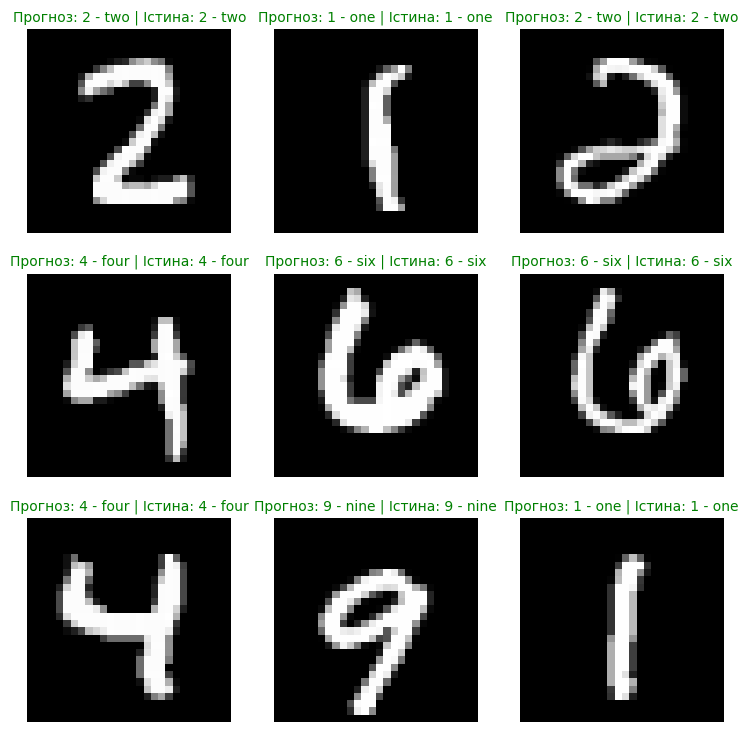

In [ ]:
# Побудова прогнозів
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Створити підграфік
  plt.subplot(nrows, ncols, i+1)

  # Побудувати цільове зображення
  plt.imshow(sample.squeeze(), cmap="gray")

  # Знайти мітку прогнозу (в текстовій формі, наприклад, "Сандалі")
  pred_label = class_names[pred_classes[i]]

  # Отримати істинну мітку (в текстовій формі, наприклад, "Футболка")
  truth_label = class_names[test_labels[i]]

  # Створити текст заголовка графіка
  title_text = f"Прогноз: {pred_label} | Істина: {truth_label}"

  # Перевірити на рівність і змінити колір заголовка відповідно
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # зелений текст, якщо правильно
  else:
      plt.title(title_text, fontsize=10, c="r") # червоний текст, якщо неправильно
  plt.axis(False);

## 9. Матриця плутанини

In [ ]:
# Імпортуємо tqdm для індикатора прогресу
from tqdm.auto import tqdm


y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Зроблення прогнозів"):
    # Відправка дані та цілі на цільовий пристрій
    X, y = X.to(device), y.to(device) # Ensure input data is on the correct device
    # Прямий прохід
    y_logit = model_2(X)
    # Перетворення прогнозів з логітів -> ймовірності прогнозів -> мітки прогнозів
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # зауваження: виконуйте softmax на вимірі "логітів", а не "пакету" (в даному випадку у нас розмір пакету 32, тому можна виконати на dim=1)
    # Поміщення прогнози на CPU для оцінки
    y_preds.append(y_pred.cpu())
# Об'єднання список прогнозів в тензор
y_pred_tensor = torch.cat(y_preds)

Зроблення прогнозів:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
# Імпортування оновленої версії mlxtend
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # повинна бути версія 0.19.0 або вище

0.23.4


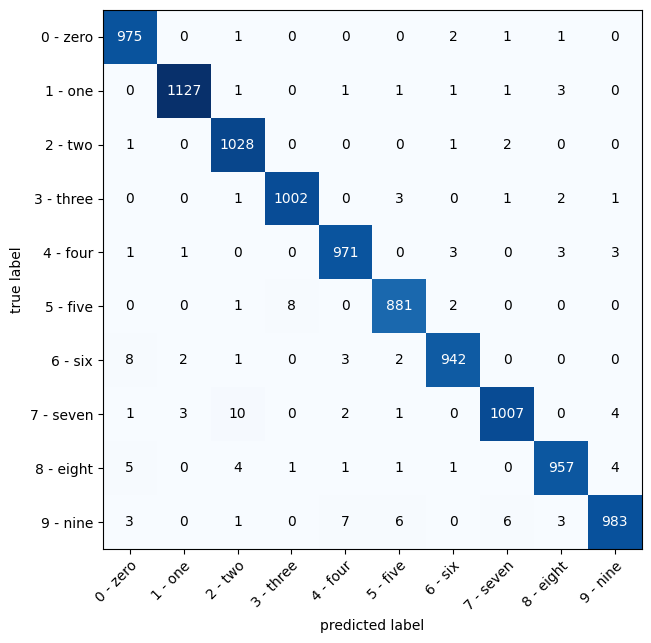

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Налаштування екземпляра матриці плутанини та порівняння прогнозів з цілями
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Побудова матриці плутанини
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib любить працювати з NumPy
    class_names=class_names, # перетворення міток рядків і стовпців на назви класів
    figsize=(10, 7)
);

Більше всього модель путає 7 з 2, що можна зрозуміти. Та 6 з 0

## 10. Приклади


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

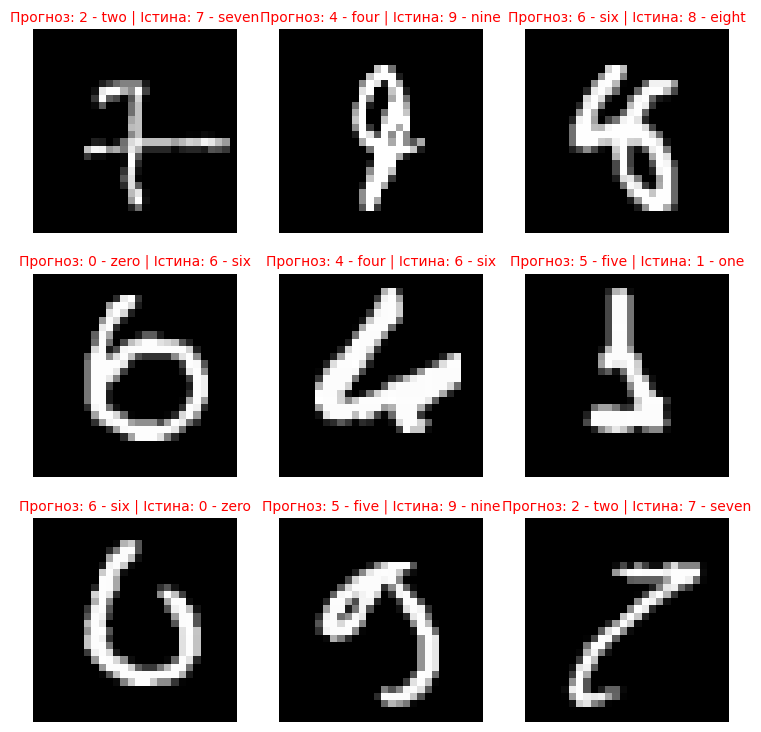

In [ ]:
# Всі прогнози моделі на тестовому наборі даних
model_2.eval()
y_preds = []
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        y_logit = model_2(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

# Індекси помилкових прогнозів
incorrect_indexes = torch.where(y_pred_tensor != test_data.targets)[0]

# Випадкові 9 помилкових прогнозів
random_incorrect_indexes = random.sample(incorrect_indexes.tolist(), k=9)

# Помилкові прогнози
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, incorrect_index in enumerate(random_incorrect_indexes):
    # Зображення та мітки
    img, truth_label = test_data[incorrect_index]
    predicted_label = class_names[y_pred_tensor[incorrect_index]]

    # Підграфік
    plt.subplot(nrows, ncols, i + 1)

    # Зображення
    plt.imshow(img.squeeze(), cmap="gray")

    # Назви класів
    truth_label_name = class_names[truth_label]

    # Текст заголовка
    title_text = f"Прогноз: {predicted_label} | Істина: {truth_label_name}"

    # Заголовок
    plt.title(title_text, fontsize=10, c="r") # Червоний для помилкових прогнозів
    plt.axis(False);

Помилка точно в данних. Якщо людина не може розрізнити, то і модель не зможе, бо створена по нашому подобію. Але її просто треба навчати на більшому наборі даних. (Можливо окремо на неякісному наборі?)

## 11. Випадковий тензор

In [ ]:
import torch
from torch import nn

# 1. Створення випадкового тензора
random_tensor = torch.randn(1, 3, 64, 64)
print(f"Форма вхідного тензора: {random_tensor.shape}")

# 2. Визначення шару nn.Conv2d() з kernel_size=3
conv_layer_small_kernel = nn.Conv2d(in_channels=3,
                                    out_channels=10,
                                    kernel_size=3,
                                    stride=1,
                                    padding=1)

# 3. Пропускання тензора через шар з малим ядром
output_tensor_small_kernel = conv_layer_small_kernel(random_tensor)
print(f"Форма вихідного тензора з kernel_size=3: {output_tensor_small_kernel.shape}")

# 4. Визначення шару nn.Conv2d() з kernel_size=7
conv_layer_large_kernel = nn.Conv2d(in_channels=3,
                                    out_channels=10,
                                    kernel_size=7,
                                    stride=1,
                                    padding=1)

# 4. Пропускання тензора через шар з великим ядром
output_tensor_large_kernel = conv_layer_large_kernel(random_tensor)
print(f"Форма вихідного тензора з kernel_size=7: {output_tensor_large_kernel.shape}")

Форма вхідного тензора: torch.Size([1, 3, 64, 64])
Форма вихідного тензора з kernel_size=3: torch.Size([1, 10, 64, 64])
Форма вихідного тензора з kernel_size=7: torch.Size([1, 10, 60, 60])


Зі збільшенням параметра kernel_size у шарі nn.Conv2d(), просторові розмірності вихідного тензора зазвичай зменшуються. Навпаки, менший kernel_size менш схильний значно зменшувати просторові розмірності. Це відбувається тому, що більше ядро покриває більшу область вхідного зображення за один крок, вимагаючи менше кроків для проходження всього зображення, тоді як заповнення (padding) допомагає компенсувати це зменшення, ефективно "розширюючи" межі входу.